##Step 1 – Choose a Data Source

Kaggle dataset

In [24]:
import pandas as pd
import numpy as np
import os

##Step 2 – Describe Your Dataset

1. What is your data source?

Our data source is a House Price CSV dataset containing information about different residential properties. It includes property details such as area, bedrooms, bathrooms, location, and price.

2. Why did you choose it?

We chose this dataset because it is simple to understand and contains useful house-related information. It is also suitable for applying different ETL transformations and generating reports.

3. What information does it contain?

It contains information about property ID, city, property type, area, bedrooms, bathrooms, floors, parking, year built, furnishing status, price per square foot, and house price.

4. Is it structured, semi-structured, or unstructured?

It is a structured dataset because the data is organized in rows and columns in CSV format.

5. What format is the data?

It is a structured dataset because the data is organized in rows and columns in CSV format.

6. How frequently is the data updated?

The data is updated only when new house price information is added to the dataset. For our project, the dataset is used as a fixed CSV file and is not automatically updated.



# Step 3 – Design Your ETL Pipeline

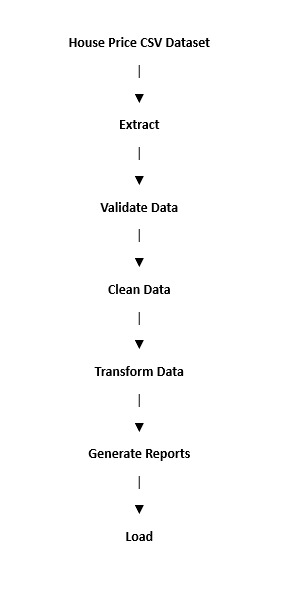

##Step 5 – Extract Function

In [42]:
## extract

def extract():
    # 1. Connect to / read the chosen data source
    file_path = "/content/Mini_Project/raw_data"
    df_house = pd.read_csv('/content/Mini_Project/raw_data/House Price Prediction Dataset.csv')

    # 2. Display number of records
    print("Number of records:", len(df_house))

    # 3. Display number of columns
    print("Number of columns:", len(df_house.shape))
    return df_house

In [43]:
extract()

Number of records: 2000
Number of columns: 2


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


##Step 6 – Transform Function

In [44]:
def transform(data):
  # Check duplicate records
  print("Duplicate records:", data.duplicated().sum())

  # Remove duplicate records
  data = data.drop_duplicates()

  # Check again after removing
  print("Duplicate records after removal:", data.duplicated().sum())

  #2.# Check missing values
  print("Missing values before handling:")
  print(data.isnull().sum())
  data = data.rename(columns={
      'Id': 'House_ID',
      'Area': 'Area_sqft',
      'Bedrooms': 'Bedrooms',
      'Bathrooms': 'Bathrooms',
      'Floors': 'Floors',
      'YearBuilt': 'Year_Built',
      'Location': 'Location',
      'Condition': 'Condition',
      'Garage': 'Garage',
      'Price': 'Price'
  })

  # Display renamed columns
  print(data.columns)
  #4 remove unwanted colunms
  data = data.drop('House_ID', axis=1)
  print(data.columns)
  ##5 Change data types

  data.dtypes
  # Change data types
  data['Area_sqft'] = data['Area_sqft'].astype(float)
  data['Price'] = data['Price'].astype(float)

  print(data.dtypes)

  #6.Sort records
  data = data.sort_values(by='Price', ascending=False)

  print(data['Price'])
  #Filter records
  # Filter records based on Price
  filtered_data = data[data['Price'] > 500000]

  # Display filtered records
  print(filtered_data)
  # 8 Remove invalid values
  data = data[
      (data['Area_sqft'] > 0) &
      (data['Price'] > 0)
  ]

  print("Records after removing invalid values:", len(data))
  return data

##Step 7 – Generate Reports

In [45]:
import os

def load(cleaned_data):
  # Create reports directory if it doesn't exist
  reports_dir = '/content/Mini_Project/reports'
  os.makedirs(reports_dir, exist_ok=True)

# 1. Complete cleaned dataset
  cleaned_data.to_csv(os.path.join(reports_dir, 'complete_cleaned_dataset.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'complete_cleaned_dataset.csv')}")

# 2. Top 10 records
  top_10_records = cleaned_data.head(10)
  top_10_records.to_csv(os.path.join(reports_dir, 'top_10_records.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'top_10_records.csv')}")

# 3. Summary statistics
  summary_stats = cleaned_data.describe()
  summary_stats.to_csv(os.path.join(reports_dir, 'summary_stats.csv'), index=False)

  print(f"Report saved: {os.path.join(reports_dir, 'summary_stats.csv')}")

##Step 9 – Build the Pipeline

In [46]:
def run_pipeline():
  raw_data = extract()
  cleaned_data = transform(raw_data)
  load(cleaned_data)

In [47]:
run_pipeline()

Number of records: 2000
Number of columns: 2
Duplicate records: 0
Duplicate records after removal: 0
Missing values before handling:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
Index(['House_ID', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors',
       'Year_Built', 'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Year_Built',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')
Area_sqft     float64
Bedrooms        int64
Bathrooms       int64
Floors          int64
Year_Built      int64
Location       object
Condition      object
Garage         object
Price         float64
dtype: object
1004    999656.0
1787    999453.0
1006    998128.0
1552    998084.0
241     997719.0
          ...   
1463     52024.0
1592     51845.0
1728     51082.0
836      50064.0
1167     50005.0
Name: P